# Clustering en online retail

En el siguiente script implementaremos 2 hipotesis para realizar clustering y al final se realiza

## 1. Traer la base de datos y librerias 

In [466]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import   StandardScaler,  FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from IPython.display import Markdown
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import plotly.express as px
from sklearn.cluster import KMeans

In [467]:
online_r=fetch_ucirepo(id=352)

In [468]:
df = online_r.data.original

## 2. EDA y Transformación

In [469]:
df.shape

(541909, 8)

In [470]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [471]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [472]:
# Cambio de lectura del formato fecha
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

In [473]:
# Detección de nulos dentro del df
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [474]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [475]:
# Se realiza la deteccion de duplicados
duplicados= df[df.duplicated()]
duplicados.shape[0]

5268

In [476]:
#Se eliminaron los duplicados
df=df.drop_duplicates(keep='first')
df.shape

(536641, 8)

Se eliminan las filas duplicadas que representan aproximadamente el 1% del df

In [477]:
541909-df.shape[0]

5268

### 2.1. Transformación logarítmica 
Se aplica para reducir la asimetría y el efecto de valores extremos en la visualización.

In [478]:
# se realiza transforamcion del logaritmo para poder graficar teniendo en cuenta valores negativos
df["Quantity_log"] = np.log1p(df["Quantity"])
df["UnitPrice_log"] = np.log1p(df["UnitPrice"])

c:\Users\workw\Documents\Met aprendizaje automatico\Hipotesis_no_supervisado\Github\Clustering\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\workw\Documents\Met aprendizaje automatico\Hipotesis_no_supervisado\Github\Clustering\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


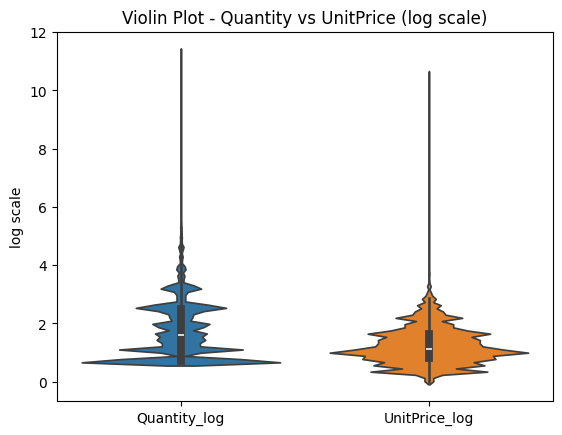

In [479]:
plt.figure()
sns.violinplot(data=df[["Quantity_log", "UnitPrice_log"]])
plt.title("Violin Plot - Quantity vs UnitPrice (log scale)")
plt.ylabel("log scale")
plt.show()

- La variable **Quantity** tiene muchos valores pequeños y unos pocos extremadamente grandes con una distribución asimétrica positiva.
- **UnitPrice** la densidad está un poco más repartida que en **Quantity_log**, pero igualmente predominan precios unitarios bajos.

Ambas distribuciones están sesgadas hacia la derecha, incluso después de la transformación logarítmica.

### 2.2. Interpretación de las variables

In [480]:
# Se encontro y se supone que todas las devoluciones autenticas comienzan por la letra C por 3 razones
# 1 la cantidad es negativa
# 2 el precio es positivo 
# 3 hay customer ID
Devoluciones=df.loc[df["InvoiceNo"].astype(str).str.startswith("C")]
Devoluciones

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-inf,3.349904
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-inf,1.731656
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,NaN,0.974560
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,NaN,0.254642
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,NaN,0.254642
...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,NaN,0.604316
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,-inf,5.419162
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,NaN,2.480731
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,-inf,0.810930


In [481]:
Devoluciones.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID        379
Country             0
Quantity_log     5167
UnitPrice_log       0
dtype: int64

**NO SE INCLUIRA EN EL MODELO LAS DEVOLUCIONES PUESTO QUE NO ES EL OBJETIVO DEL PROYECTO**

Transacciones internas de la empresa

In [482]:
# se supone que si tiene cantidad negativa y no comienza por la letra C es porque 
#son transacciones de la empresa
df_interno_1 = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]
df_interno_1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,NaN,0.0
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom,NaN,0.0
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,NaN,0.0
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,NaN,0.0
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom,NaN,0.0
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom,NaN,0.0
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom,NaN,0.0
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom,NaN,0.0


In [483]:
# Puede que haya transacciones por fuera de los valores anteriores (es decir con UnitPrice == 0) que tengan cantidades positivas, 
# y este tipo de transacciones son operaciones de la empresa 
df_interno_2 = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] == 0)
]
df_interno_2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,4.043051,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.693147,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.693147,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.693147,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.693147,0.0
...,...,...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,2011-12-07 18:36:00,0.0,NaN,United Kingdom,2.708050,0.0
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,3.332205,0.0
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,5.484797,0.0
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,5.707110,0.0


In [484]:
# La suma de 1174 + 1336 es igual a todos los valores con precio 0
df_interno_completo = df[
    (df["UnitPrice"] == 0)]
df_interno_completo

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,4.043051,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.693147,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.693147,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.693147,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.693147,0.0
...,...,...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,3.332205,0.0
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,5.484797,0.0
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,5.707110,0.0
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom,3.044522,0.0


**Se decide BORRAR TODAS las columnas con UNIT PRICE = 0 por los motivos antes mencionados, tener en cuenta que esto es RUIDO generado por las operaciones de la empresa**

In [485]:
# Revision transacciones con una sola letra en la columna de Stock Code
Transaccioon_letra1 =df[
    (df["StockCode"].astype(str).str.len() == 1) &
    (df["StockCode"].astype(str).str.isalpha())
]
Transaccioon_letra1["StockCode"].value_counts()

StockCode
M    566
D     77
S     62
B      3
m      1
Name: count, dtype: int64

**Se decide BORRAR todas las filas de StockCode que tengan una sola letra letra ya que son operaciones de la empresa definidas M= Manual, D= discount , S= samples, B= bads, etc**

In [486]:
#cuantos paises hay. 
Paises=df["Country"].value_counts()
Paises

Country
United Kingdom          490300
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [487]:
# Porcentaje de los datos que corresponden a Reino Unido
Paises=Paises.reset_index(drop=True)
Paises.loc[0]/Paises.sum() *100

np.float64(91.36461805937303)

Vale la pena hacer solamente un modelo para UK debido a que esta desbalanceado ya que el 91% de los datos son de UK y por lo tanto estaria sesgado interpretarlo con los datos de varios paises.

### 2.3. DATA CLEANING
Descarte de las variables UNIT PRICE = 0, DEVOLUCIONES Y COMPRAS HECHAS EN EL RESTO DEL MUNDO EXCLUYENDO EL REINO UNIDO

- LIMPIEZA UNIT PRICE = 0 & STOCK CODE = SOLO UNA LETRA & SOCK CODE REVISION MANUAL = GITFT,PAD,POST, DOT, CRUK, BANK CHARGES, AMAZON FEE 

In [488]:
# Limpieza previa
df["StockCode"] = df["StockCode"].astype(str).str.strip().str.lower()

# Lista manual
invalid_codes = ["gift", "pad", "post", "dot", "cruk", "bank charges", "amazon fee"]

# Condiciones
cond_price = df["UnitPrice"] == 0
cond_negative_Quantity = df['Quantity'] < 0
cond_one_letter = (
    (df["StockCode"].str.len() == 1) &
    (df["StockCode"].str.isalpha())
)

cond_manual = df["StockCode"].isin(invalid_codes)

# Filtro final (mantener lo válido)
df_clean = df[~(cond_price | cond_one_letter | cond_manual | cond_negative_Quantity)]

In [489]:
# impresion de lectura de los datos removidos
df_removed = df[cond_price | cond_one_letter | cond_manual| cond_negative_Quantity]
df_removed

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
45,536370,post,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France,1.386294,2.944439
141,C536379,d,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-inf,3.349904
154,C536383,35004c,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-inf,1.731656
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,NaN,0.974560
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,NaN,0.254642
...,...,...,...,...,...,...,...,...,...,...
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,-inf,0.810930
541717,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,NaN,0.810930
541730,581570,post,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany,0.693147,2.944439
541767,581574,post,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany,1.098612,2.944439


In [490]:
df_clean.shape

(522714, 10)

In [491]:
# cantidad de filas original, filtrada y cantidad removida
len(df), len(df_clean), len(df_removed)

(536641, 522714, 13927)

## 3 Procesamiento de los datos

In [492]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

Se realiza filtro por UK Y resto del mundo para revisar el radio de valor entre transacciones.

In [493]:
# filtro de UK
UK_df= df_clean[df_clean['Country']=='United Kingdom']
# Dinero UK 
dinero_UK=df_clean.loc[df_clean['Country'] == 'United Kingdom','TotalPrice'].sum()
# Transacciones de UK
T_UK=df_clean.loc[df_clean['Country'] == 'United Kingdom','TotalPrice'].count()
#Radio de UK
rate_UK=dinero_UK / T_UK
rate_UK

np.float64(18.249510004447348)

In [494]:
# Se borrarion el CustomerID nulo porque se supone que son transacciones de la empresa, y no aportan nada a la hora de hacer el clustering
ratio_null_customerid=(UK_df['CustomerID'].isnull().sum()/len(UK_df))*100
ratio_null_customerid

np.float64(27.150126217018105)

In [495]:
Markdown(f"""
Se crea el modelo RFM a nivel cliente usando CustomerID, TotalPrice, InvoiceDate este modelo 
tiene la caracteristica que no tendra en cuenta las transacciones que no tengan el identificador de ID por lo tanto
         seran descartado el siguiente % de filas del df como parte final  
         



 **{ratio_null_customerid:.2f}%** 

""")


Se crea el modelo RFM a nivel cliente usando CustomerID, TotalPrice, InvoiceDate este modelo 
tiene la caracteristica que no tendra en cuenta las transacciones que no tengan el identificador de ID por lo tanto
         seran descartado el siguiente % de filas del df como parte final  




 **27.15%** 



### 3.1. Creacion del RFM

- RFM: Recency(ultimos dias de compra), frequency(cuantas compras hizo) and monetary(cuanto gasto el cliente en total)



In [496]:
snapshot_date = UK_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = UK_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12747.0,2,11,4196.01
2,12748.0,1,206,31650.78
3,12749.0,4,5,4090.88
4,12820.0,3,4,942.34
...,...,...,...,...
3911,18280.0,278,1,180.60
3912,18281.0,181,1,80.82
3913,18282.0,8,2,178.05
3914,18283.0,4,16,2039.58


Se realizaran dos modelos de clustering como se muestra en la siguiente figura:


![ChatGPT Image 31 mar 2026, 09_50_44 a.m..png](<attachment:ChatGPT Image 31 mar 2026, 09_50_44 a.m..png>)
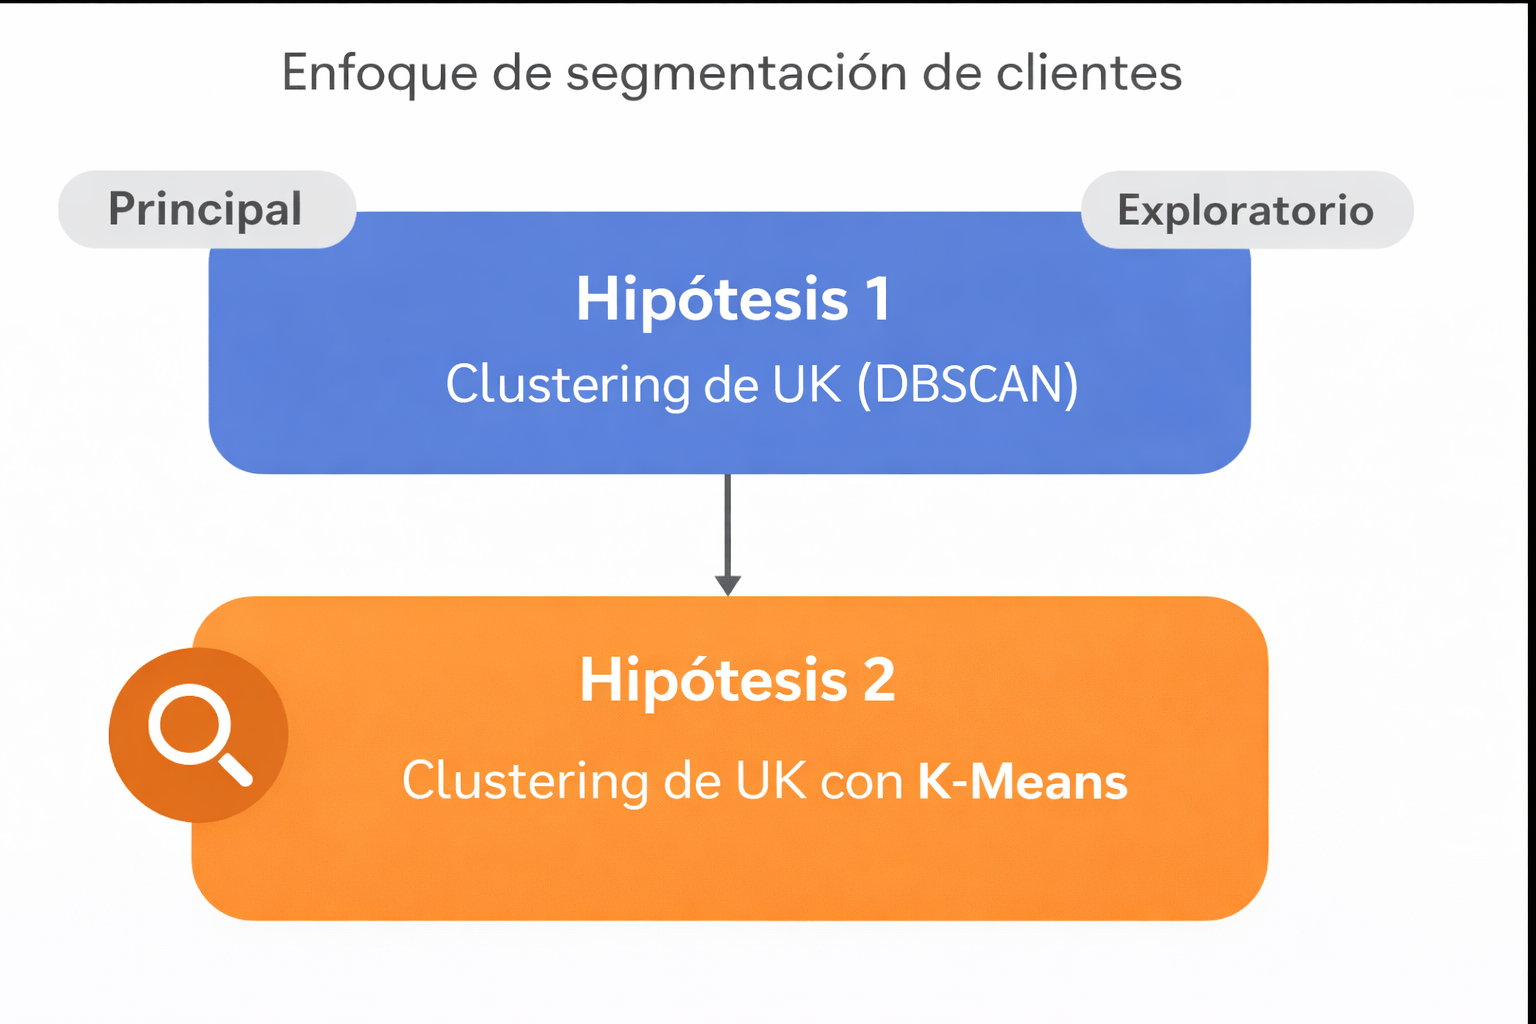

## 4. Construcción del modelo, estimación del número de clusters a generar y evaluación de los resultados

### 4.1. DBSCAN - Hipotesis 1

#### 4.1.1. PIPELINE DE TRANFORMACION NUMERICA y DBSCAN

In [497]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

In [498]:
pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler()),
    ("dbscan", DBSCAN(eps=0.6, min_samples=5))
])

pipeline.fit(X)
labels = pipeline.named_steps['dbscan'].labels_

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('log', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... version

In [499]:
#Escala Log para grafico DBSCAN
X_trans = pipeline[:-1].transform(X)
X_trans_df = pd.DataFrame(
    X_trans,
    columns=["Recency_log_scaled", "Frequency_log_scaled", "Monetary_log_scaled"]
)

X_trans_df["cluster"] = labels

#### Figura 4.1. Grafico de dispersión 

In [500]:
#Grafico DBSCAN
X_plot = X_trans_df.copy()
X_plot["cluster"] = X_plot["cluster"].astype(str)

fig = px.scatter_3d(
    X_plot,
    x="Recency_log_scaled",
    y="Frequency_log_scaled",
    z="Monetary_log_scaled",
    color="cluster",
    title="DBSCAN en espacio transformado",
    opacity=0.7
)

fig.show()

In [501]:
# Medidas de número de clusters y silhouette
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Número de clusters:", n_clusters)
print("Número de puntos ruido:", n_noise)
print("Porcentaje de ruido:", n_noise / len(labels))

# Aplicar las transformaciones en el mismo orden del pipeline
X_log = pipeline.named_steps["log"].transform(X)
X_scaled = pipeline.named_steps["scaler"].transform(X_log)

mask = labels != -1

if len(set(labels[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette:", sil)
else:
    print("No se puede calcular silhouette: hace falta más de un cluster sin contar ruido.")

Número de clusters: 2
Número de puntos ruido: 32
Porcentaje de ruido: 0.008171603677221655
Silhouette: 0.571516509377113


#### 4.1.2. Estimación de hiperparametros y numero de cluster para DBSCAN 

In [502]:
#tamaño optimo de hiperparametros 2

for eps in [0.2, 0.3, 0.4, 0.5, 0.6]:
    for min_samples in [5, 10, 15]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_trans)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.sum(labels == -1) / len(labels)

        mask = labels != -1

        if n_clusters > 1 and np.sum(mask) > 0:
            score = silhouette_score(X_trans[mask], labels[mask])
            print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={noise_ratio:.2f}, silhouette_score={score:.3f}")

eps=0.2, min_samples=5, clusters=32, noise=0.16, silhouette_score=-0.037
eps=0.2, min_samples=10, clusters=13, noise=0.31, silhouette_score=0.111
eps=0.2, min_samples=15, clusters=6, noise=0.43, silhouette_score=0.146
eps=0.3, min_samples=5, clusters=10, noise=0.06, silhouette_score=0.065
eps=0.3, min_samples=10, clusters=6, noise=0.11, silhouette_score=0.065
eps=0.3, min_samples=15, clusters=5, noise=0.16, silhouette_score=0.080
eps=0.4, min_samples=5, clusters=4, noise=0.02, silhouette_score=0.133
eps=0.4, min_samples=10, clusters=3, noise=0.04, silhouette_score=0.180
eps=0.4, min_samples=15, clusters=3, noise=0.06, silhouette_score=0.187
eps=0.5, min_samples=5, clusters=2, noise=0.01, silhouette_score=0.298
eps=0.5, min_samples=10, clusters=2, noise=0.02, silhouette_score=0.299
eps=0.5, min_samples=15, clusters=2, noise=0.03, silhouette_score=0.302
eps=0.6, min_samples=5, clusters=2, noise=0.01, silhouette_score=0.572


Aunque DBSCAN encontró 2 clusters y un silhouette alto (0.572), eso no garantiza que la segmentación sea la mejor para el negocio ni la más útil para perfilar clientes. En el gráfico se ve que hay un: 
- cluster dominante enorme
- un cluster muy pequeño,
- muy pocos puntos marcados como ruido.

Eso sugiere que DBSCAN está separando más bien una zona densa principal y un grupo reducido de casos particulares, pero no está generando segmentos de clientes equilibrados e interpretables. Por tal motivo, con los datos ya entrenados, intentaremos la opcion del k-means debido a que es nuestra segunda hipotesis.

### 4.2. K-means y hipotesis 2

#### 4.2.1. PIPELINE DEL K-means

In [503]:
#pipeline kmeans
pipeline_kmeans = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=7, random_state=42, n_init=20))
])

pipeline_kmeans.fit(X)
labels_kmeans = pipeline_kmeans.named_steps["kmeans"].labels_

In [504]:
X_kmeans_trans = pipeline_kmeans[:-1].transform(X)
sil_kmeans = silhouette_score(X_kmeans_trans, labels_kmeans)
print("Silhouette KMeans:", sil_kmeans)

Silhouette KMeans: 0.31172635373552054


In [505]:
#hiperparametros kmeans
for k in range(2, 21):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_trans)
    score = silhouette_score(X_trans, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.435
k=3, silhouette=0.342
k=4, silhouette=0.339
k=5, silhouette=0.318
k=6, silhouette=0.315
k=7, silhouette=0.312
k=8, silhouette=0.305
k=9, silhouette=0.284
k=10, silhouette=0.283
k=11, silhouette=0.278
k=12, silhouette=0.275
k=13, silhouette=0.272
k=14, silhouette=0.274
k=15, silhouette=0.270
k=16, silhouette=0.276
k=17, silhouette=0.277
k=18, silhouette=0.276
k=19, silhouette=0.280
k=20, silhouette=0.279


Vemos que idealmente kmeans tambien clasifica alrededor de 0.43 con 2 clusters, mas alla de eso podemos irnos hasta k=7 en donde tenemos un poco mas de grupos para ver y la bajada no es significativamente alta.

## 5. ANALISIS DE LOS RESULTADOS

In [506]:
X_k_trans = pipeline_kmeans[:-1].transform(X)

import pandas as pd

X_k_df = pd.DataFrame(
    X_k_trans,
    columns=["Recency_log_scaled", "Frequency_log_scaled", "Monetary_log_scaled"]
)

X_k_df["cluster"] = labels_kmeans.astype(str)

fig = px.scatter_3d(
    X_k_df,
    x="Recency_log_scaled",
    y="Frequency_log_scaled",
    z="Monetary_log_scaled",
    color="cluster",
    title="KMeans clusters",
    opacity=0.7
)

fig.show()

El modelo K-Means con 7 clusters permitió identificar segmentos de clientes con comportamientos claramente distintos en términos de Recency, Frequency y Monetary, lo que lo hace útil para estrategias de marketing y gestión comercial. Aunque el silhouette no es el más alto posible, la solución sí ofrece perfiles interpretables y accionables.

Resumen por cluster:


,cluster,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median,Count,Pct_customers
5,5,7.971154,4.5,24.254808,19.0,15785.747067,7694.925,208,5.311542
1,1,49.445614,37.0,6.568421,6.0,2868.478333,2183.360,570,14.555669
4,4,6.261838,5.0,7.161560,7.0,2353.337409,2085.080,359,9.167518
6,6,124.997361,103.5,2.489446,2.0,902.284711,756.285,758,19.356486
3,3,17.293913,17.0,2.817391,3.0,759.609741,682.910,575,14.683350
2,2,44.723810,44.0,1.217460,1.0,261.257732,243.555,630,16.087845
0,0,241.047794,243.0,1.158088,1.0,239.846042,214.315,816,20.837589


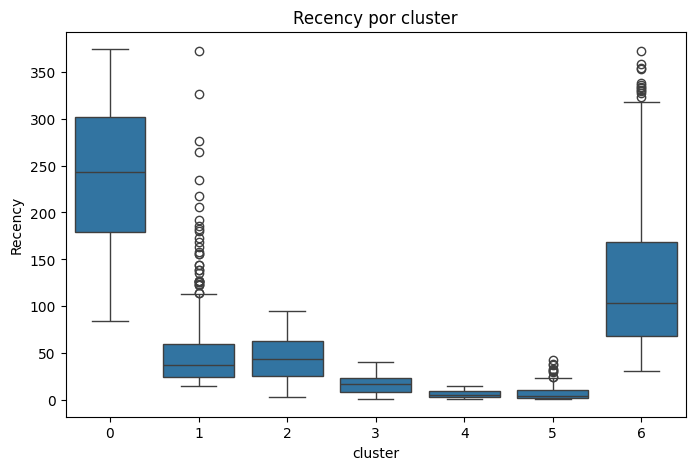

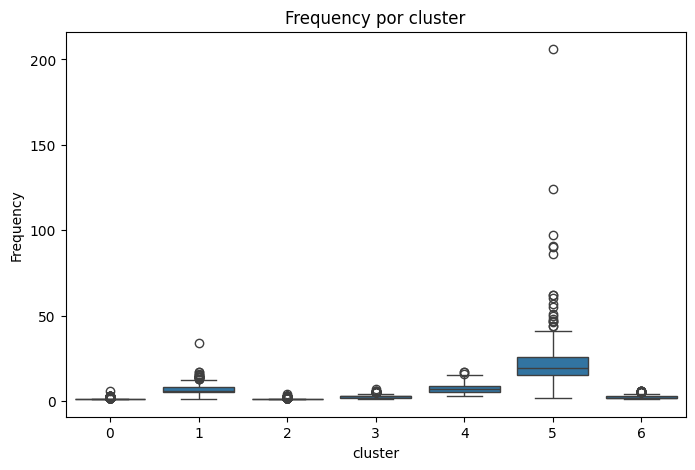

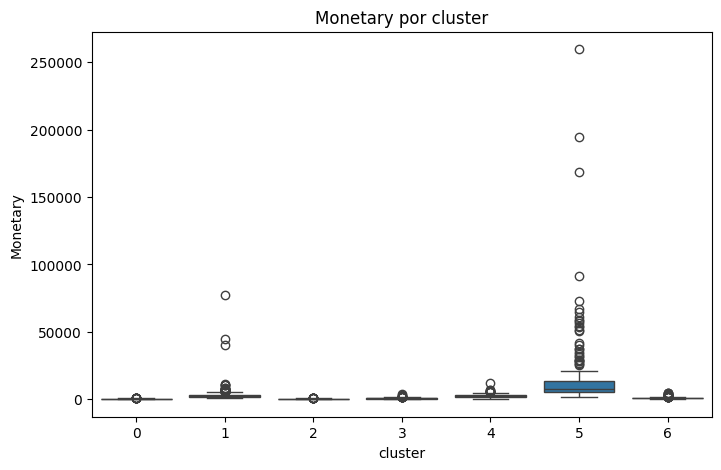


Resumen con interpretación:


,cluster,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median,Count,Pct_customers,Perfil
5,5,7.971154,4.5,24.254808,19.0,15785.747067,7694.925,208,5.311542,VIP / Alto valor
1,1,49.445614,37.0,6.568421,6.0,2868.478333,2183.360,570,14.555669,Intermedio / Regular
4,4,6.261838,5.0,7.161560,7.0,2353.337409,2085.080,359,9.167518,Intermedio / Regular
6,6,124.997361,103.5,2.489446,2.0,902.284711,756.285,758,19.356486,Intermedio / Regular
3,3,17.293913,17.0,2.817391,3.0,759.609741,682.910,575,14.683350,Intermedio / Regular
2,2,44.723810,44.0,1.217460,1.0,261.257732,243.555,630,16.087845,Bajo valor
0,0,241.047794,243.0,1.158088,1.0,239.846042,214.315,816,20.837589,Inactivos / Riesgo de abandono


In [507]:
# 1) Crear dataframe con labels
rfm_clustered = rfm.copy()
rfm_clustered["cluster"] = labels_kmeans

# 2) Resumen estadístico por cluster
cluster_summary = rfm_clustered.groupby("cluster").agg(
    Recency_mean=("Recency", "mean"),
    Recency_median=("Recency", "median"),
    Frequency_mean=("Frequency", "mean"),
    Frequency_median=("Frequency", "median"),
    Monetary_mean=("Monetary", "mean"),
    Monetary_median=("Monetary", "median"),
    Count=("CustomerID", "count")
).reset_index()

# 3) Porcentaje de clientes por cluster
cluster_summary["Pct_customers"] = cluster_summary["Count"] / len(rfm_clustered) * 100

# 4) Ordenar por gasto promedio para entender mejor
cluster_summary = cluster_summary.sort_values(by="Monetary_mean", ascending=False)

# 5) Mostrar tabla resumen
print("Resumen por cluster:")
display(cluster_summary)

# 6) Boxplots para interpretar comportamiento por cluster
plt.figure(figsize=(8,5))
sns.boxplot(data=rfm_clustered, x="cluster", y="Recency")
plt.title("Recency por cluster")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=rfm_clustered, x="cluster", y="Frequency")
plt.title("Frequency por cluster")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=rfm_clustered, x="cluster", y="Monetary")
plt.title("Monetary por cluster")
plt.show()

# 7) Perfil cualitativo automático simple
def interpretar_cluster(row):
    r = row["Recency_mean"]
    f = row["Frequency_mean"]
    m = row["Monetary_mean"]
    
    if m > cluster_summary["Monetary_mean"].quantile(0.75) and f > cluster_summary["Frequency_mean"].quantile(0.75):
        return "VIP / Alto valor"
    elif r > cluster_summary["Recency_mean"].quantile(0.75) and f < cluster_summary["Frequency_mean"].quantile(0.25):
        return "Inactivos / Riesgo de abandono"
    elif r < cluster_summary["Recency_mean"].quantile(0.25) and f < cluster_summary["Frequency_mean"].quantile(0.5):
        return "Nuevos / Recientes"
    elif m < cluster_summary["Monetary_mean"].quantile(0.25) and f < cluster_summary["Frequency_mean"].quantile(0.25):
        return "Bajo valor"
    else:
        return "Intermedio / Regular"

cluster_summary["Perfil"] = cluster_summary.apply(interpretar_cluster, axis=1)

print("\nResumen con interpretación:")
display(cluster_summary)

1. 

## 6. Conclusiones del modelo:
A partir de las figuras y tablas anteriores, se determino que: 

In [508]:
interpretacion = pd.DataFrame({
    "cluster": [5,4,1,3,6,2,0],
    "tipo": [
        "VIP",
        "Activos valiosos",
        "Leales",
        "Recientes",
        "Dormidos",
        "Bajo valor",
        "Inactivos (Churn)"
    ],
    "descripcion": [
        "Alta frecuencia, alto gasto, recientes",
        "Activos con buen gasto",
        "Frecuentes pero menos recientes",
        "Clientes nuevos o en crecimiento",
        "Han dejado de comprar",
        "Compras ocasionales",
        "Clientes perdidos"
    ]
})

display(interpretacion)

,cluster,tipo,descripcion
0,5,VIP,"Alta frecuencia, alto gasto, recientes"
1,4,Activos valiosos,Activos con buen gasto
2,1,Leales,Frecuentes pero menos recientes
3,3,Recientes,Clientes nuevos o en crecimiento
4,6,Dormidos,Han dejado de comprar
5,2,Bajo valor,Compras ocasionales
6,0,Inactivos (Churn),Clientes perdidos


Aunque el valor máximo del índice silhouette se obtuvo con k=2 para el DBSCAN, este número de clusters resulta insuficiente para capturar la heterogeneidad del comportamiento de los clientes. Se seleccionó un valor de k igual a 7, donde el silhouette se mantiene en rangos aceptables (0.30), permitiendo una segmentación más rica e interpretable desde el punto de vista del negocio. Adicionalmente, se evaluaron métricas complementarias y la coherencia de los perfiles obtenidos, priorizando la utilidad práctica de la segmentación, para segmentar mejor la caracterizacion de los clientes.

In [509]:
sil = silhouette_score(X_trans, labels_kmeans)
dbi = davies_bouldin_score(X_trans, labels_kmeans)
chi = calinski_harabasz_score(X_trans, labels_kmeans)

print("Silhouette:", sil)
print("Davies-Bouldin:", dbi)

print("Calinski-Harabasz:", chi)

Silhouette: 0.31172635373552054
Davies-Bouldin: 0.9672313536860021
Calinski-Harabasz: 2746.153575116994


In [510]:
resultados=[]
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_trans)

    sil = silhouette_score(X_trans, labels)
    dbi = davies_bouldin_score(X_trans, labels)
    chi = calinski_harabasz_score(X_trans, labels)

    resultados.append({
        "k": k,
        "Silhouette": sil,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    })

tabla_metricas = pd.DataFrame(resultados)
tabla_metricas

,k,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.435295,0.886112,4009.251547
1,3,0.342074,1.033819,3351.651466
2,4,0.338628,1.010321,3076.070826
3,5,0.318341,0.979958,2947.852988
4,6,0.314810,1.006478,2851.584606
5,7,0.311726,0.967231,2746.153575
6,8,0.304748,0.980776,2626.231643
7,9,0.284129,1.001452,2536.358950
8,10,0.282982,1.007408,2468.902545


Esto sugiere que, a partir de cierto punto, agregar más clusters aporta más detalle, pero no necesariamente mejora la separación real entre segmentos. Estadísticamente, k=2 es la mejor partición. Sin embargo, para fines de negocio y segmentación de clientes, una solución con más clusters puede ser preferible, ya que permite identificar perfiles más específicos y accionables, aunque con una leve pérdida en calidad métrica.